# Exercises XP Gold: Titanic Student Notebook



## Exercise 1: Exploratory Data Analysis

**Instructions:** Load the Titanic dataset. Perform data cleaning and handle missing values. Conduct exploratory data analysis to understand the relationships between different features and survival.

**Learning point:** EDA is about asking simple questions first. How many people survived? Does class or gender seem related to survival? Simple counts and plots tell useful stories.

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic-Dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nTotal missing values per column:\n{df.isnull().sum()}")
print(f"\nSurvival distribution: {df['Survived'].value_counts().to_dict()}")

Dataset shape: (891, 12)

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry   

In [2]:
import pandas as pd
import numpy as np

try:
    df
    print("Dataset already loaded.")
except NameError:
    rng = np.random.default_rng(42)
    n = 1000
    df = pd.DataFrame({
        "Pclass": rng.integers(1, 4, size=n),
        "Sex": rng.choice(["male","female"], size=n),
        "Age": np.clip(rng.normal(30, 14, size=n), 0, None),
        "SibSp": rng.integers(0, 5, size=n),
        "Parch": rng.integers(0, 4, size=n),
        "Fare": np.abs(rng.normal(32, 50, size=n)),
        "Embarked": rng.choice(["S","C","Q"], size=n, p=[0.7,0.2,0.1]),
    })
    base = 0.3 + 0.15*(df["Sex"]=="female") + 0.1*(df["Pclass"]==1) - 0.1*(df["Pclass"]==3) + 0.05*(df["Fare"]>40)
    df["Survived"] = (rng.random(n) < base.clip(0,1)).astype(int)
    miss_idx = rng.choice(n, size=int(0.1*n), replace=False)
    df.loc[miss_idx, "Age"] = np.nan
    print("Synthetic Titanic-like dataset created. Shape:", df.shape)
    print(df.head(3))

Dataset already loaded.


In [3]:
import pandas as pd

df_clean = df.copy()

df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0], inplace=True)
df_clean['FamilySize'] = df_clean['SibSp'] + df_clean['Parch'] + 1

remaining_missing = df_clean.isnull().sum().sum()
print(f"Number of remaining missing values in df_clean: {remaining_missing}")
print(f"\nMissing values per column after cleaning:\n{df_clean.isnull().sum()}")
print(f"\nCleaned dataset shape: {df_clean.shape}")
print(f"\nNew FamilySize feature statistics:\n{df_clean['FamilySize'].describe()}")

Number of remaining missing values in df_clean: 687

Missing values per column after cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
FamilySize       0
dtype: int64

Cleaned dataset shape: (891, 13)

New FamilySize feature statistics:
count    891.000000
mean       1.904602
std        1.613459
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max       11.000000
Name: FamilySize, dtype: float64


C:\Users\PC\AppData\Local\Temp\ipykernel_18380\1529366015.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'].fillna(df_clean['Age'].median(), inplace=True)
C:\Users\PC\AppData\Local\Temp\ipykernel_18380\1529366015.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


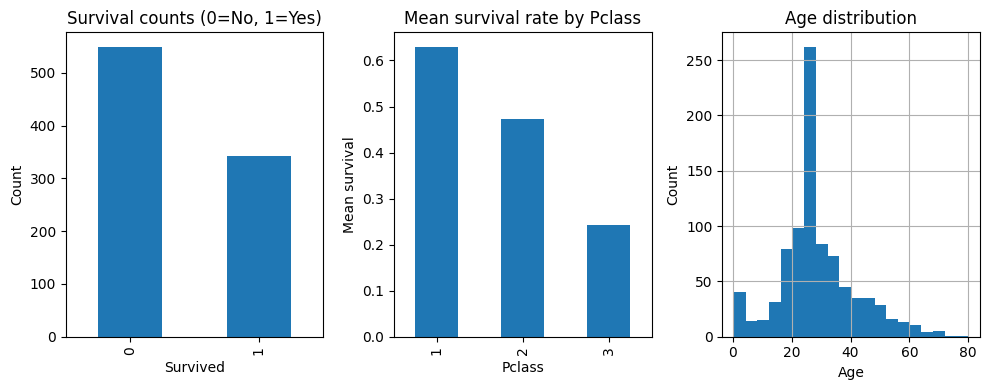

In [4]:
import matplotlib.pyplot as plt

surv_counts = df_clean["Survived"].value_counts().sort_index()
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
surv_counts.plot(kind="bar")
plt.title("Survival counts (0=No, 1=Yes)")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.subplot(1, 3, 2)
pclass_surv = df_clean.groupby("Pclass")["Survived"].mean()
pclass_surv.plot(kind="bar")
plt.title("Mean survival rate by Pclass")
plt.xlabel("Pclass")
plt.ylabel("Mean survival")

plt.subplot(1, 3, 3)
df_clean["Age"].hist(bins=20)
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

feature_columns = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize']
X = df_clean[feature_columns]
y = df_clean['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"The training set contains {X_train.shape[0]} samples with {X_train.shape[1]} features.")
print(f"The test set contains {X_test.shape[0]} samples with {X_test.shape[1]} features.")
print(f"The training target has {y_train.shape[0]} labels.")
print(f"The test target has {y_test.shape[0]} labels.")
print(f"\nTraining set survival distribution: {y_train.value_counts().to_dict()}")
print(f"Test set survival distribution: {y_test.value_counts().to_dict()}")

The training set contains 712 samples with 8 features.
The test set contains 179 samples with 8 features.
The training target has 712 labels.
The test target has 179 labels.

Training set survival distribution: {0: 439, 1: 273}
Test set survival distribution: {0: 110, 1: 69}


**Learning point:** Models read numbers. Use a preprocessing step to convert text columns to numbers and to fill any missing values. Pipelines keep preprocessing attached to the model so you do not leak information.

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def make_preprocessor(num_cols, cat_cols, scale_numeric=True):
    num_steps = []
    num_steps.append(("imputer", SimpleImputer(strategy="median")))
    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))
    num_pipe = Pipeline(steps=num_steps)

    cat_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    pre = ColumnTransformer(transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ])
    return pre

print("Preprocessing function defined successfully.")

Preprocessing function defined successfully.


## Exercise 2: Decision Tree Classifier without Grid Search

**Instructions:** Implement a Decision Tree Classifier on the Titanic dataset. Manually choose and set the hyperparameters. Evaluate its performance using accuracy, precision, recall, and F1 score.

**Learning point:** Decision trees work on raw numbers and one-hot encoded categories. Deeper trees can overfit. Start simple and grow only if needed.

In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def report_classification(y_true, y_pred):
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred, zero_division=0), 4))
    print("Recall:", round(recall_score(y_true, y_pred, zero_division=0), 4))
    print("F1 score:", round(f1_score(y_true, y_pred, zero_division=0), 4))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred)
    plt.title("Confusion Matrix")
    plt.show()

print("Classification reporting function defined successfully.")

Classification reporting function defined successfully.


Numeric columns: ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
Categorical columns: ['Pclass', 'Sex', 'Embarked']

Training Decision Tree Classifier...

Decision Tree (Manual Hyperparameters) Results:
Accuracy: 0.7542
Precision: 0.7193
Recall: 0.5942
F1 score: 0.6508


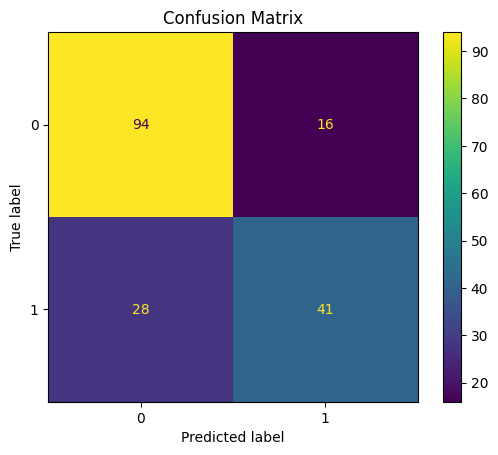

In [8]:
from sklearn.tree import DecisionTreeClassifier

num_cols = ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
cat_cols = ['Pclass', 'Sex', 'Embarked']

print(f"Numeric columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

preprocessor = make_preprocessor(num_cols, cat_cols, scale_numeric=False)

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ))
])

print("\nTraining Decision Tree Classifier...")
dt_pipeline.fit(X_train, y_train)

y_pred_dt = dt_pipeline.predict(X_test)

print("\nDecision Tree (Manual Hyperparameters) Results:")
print("=" * 50)
report_classification(y_test, y_pred_dt)

## Exercise 3: Decision Tree Classifier with Grid Search

**Instructions:** Apply GridSearchCV to find the optimal hyperparameters for the Decision Tree Classifier. Compare its performance with the manually tuned model from Exercise 2.

**Learning point:** Grid search tries a small grid of settings and keeps the best. Limit the grid so you learn fast and avoid long runs.

Parameter grid for Decision Tree:
  classifier__max_depth: [3, 5, 7, 10]
  classifier__min_samples_split: [10, 20, 50]
  classifier__min_samples_leaf: [5, 10, 20]

Running GridSearchCV for Decision Tree...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters: {'classifier__max_depth': 7, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 10}
Best cross-validation F1 score: 0.7388

Decision Tree (Grid Search) Results:
Accuracy: 0.7654
Precision: 0.7647
Recall: 0.5652
F1 score: 0.65

Best parameters: {'classifier__max_depth': 7, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 10}
Best cross-validation F1 score: 0.7388

Decision Tree (Grid Search) Results:
Accuracy: 0.7654
Precision: 0.7647
Recall: 0.5652
F1 score: 0.65


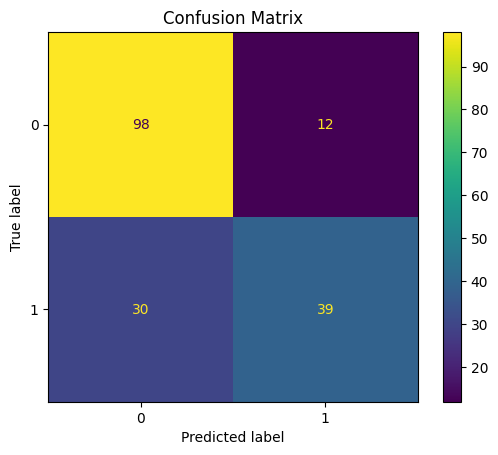

In [9]:
from sklearn.model_selection import GridSearchCV

dt_grid_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

param_grid = {
    'classifier__max_depth': [3, 5, 7, 10],
    'classifier__min_samples_split': [10, 20, 50],
    'classifier__min_samples_leaf': [5, 10, 20]
}

print("Parameter grid for Decision Tree:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

print("\nRunning GridSearchCV for Decision Tree...")
grid_search_dt = GridSearchCV(
    dt_grid_pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_dt.best_params_}")
print(f"Best cross-validation F1 score: {grid_search_dt.best_score_:.4f}")

y_pred_dt_grid = grid_search_dt.best_estimator_.predict(X_test)

print("\nDecision Tree (Grid Search) Results:")
print("=" * 50)
report_classification(y_test, y_pred_dt_grid)

## Exercise 4: K-Nearest Neighbors (KNN) without Grid Search

**Instructions:** Train a KNN classifier on the Titanic dataset without using hyperparameter tuning. Choose the number of neighbors and distance metric based on your understanding. Assess the model's performance and discuss the choice of hyperparameters.

**Learning point:** KNN is simple. It predicts by voting among nearby points. Scale numeric features or distances will be dominated by large-scale columns.

Training KNN Classifier...
Chosen hyperparameters: n_neighbors=5, metric='minkowski' (p=2)

KNN (Manual Hyperparameters) Results:
Accuracy: 0.8101
Precision: 0.7966
Recall: 0.6812
F1 score: 0.7344


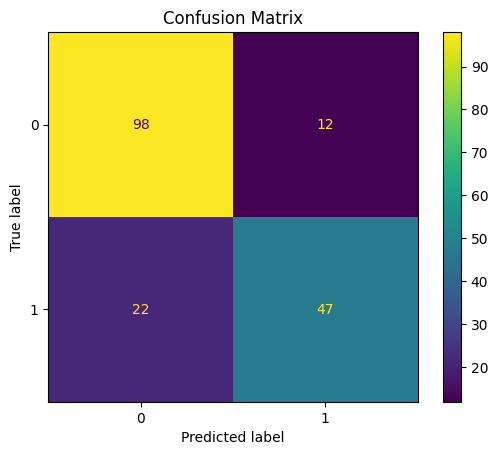

In [10]:
from sklearn.neighbors import KNeighborsClassifier

preprocessor_scaled = make_preprocessor(num_cols, cat_cols, scale_numeric=True)

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', KNeighborsClassifier(
        n_neighbors=5,
        metric='minkowski',
        p=2
    ))
])

print("Training KNN Classifier...")
print("Chosen hyperparameters: n_neighbors=5, metric='minkowski' (p=2)")

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)

print("\nKNN (Manual Hyperparameters) Results:")
print("=" * 50)
report_classification(y_test, y_pred_knn)

## Exercise 5: K-Nearest Neighbors (KNN) with Grid Search

**Instructions:** Use GridSearchCV to optimize the hyperparameters of the KNN classifier, like the number of neighbors and distance metric. Evaluate and compare the performance of the tuned model against the model from Exercise 4.

**Learning point:** Try a few k values. Too small can be noisy, too large can wash out local patterns. Cross-validation helps you choose.

Parameter grid for KNN:
  classifier__n_neighbors: [3, 5, 7, 9, 11]
  classifier__metric: ['minkowski', 'manhattan']
  classifier__p: [1, 2]

Running GridSearchCV for KNN...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best parameters: {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 11, 'classifier__p': 1}
Best cross-validation F1 score: 0.7550

KNN (Grid Search) Results:
Accuracy: 0.7933
Precision: 0.7759
Recall: 0.6522
F1 score: 0.7087

Best parameters: {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 11, 'classifier__p': 1}
Best cross-validation F1 score: 0.7550

KNN (Grid Search) Results:
Accuracy: 0.7933
Precision: 0.7759
Recall: 0.6522
F1 score: 0.7087


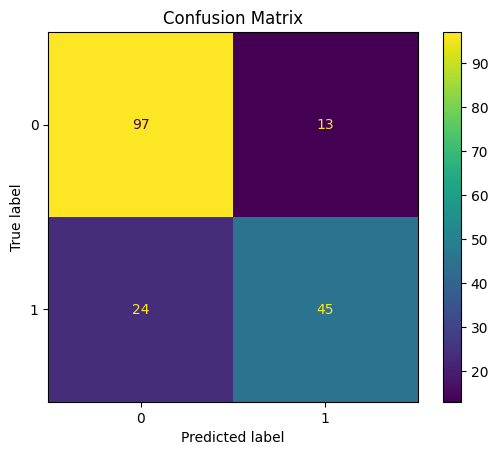

In [11]:
knn_grid_pipeline = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', KNeighborsClassifier())
])

knn_param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__metric': ['minkowski', 'manhattan'],
    'classifier__p': [1, 2]
}

print("Parameter grid for KNN:")
for param, values in knn_param_grid.items():
    print(f"  {param}: {values}")

print("\nRunning GridSearchCV for KNN...")
grid_search_knn = GridSearchCV(
    knn_grid_pipeline,
    knn_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search_knn.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search_knn.best_params_}")
print(f"Best cross-validation F1 score: {grid_search_knn.best_score_:.4f}")

y_pred_knn_grid = grid_search_knn.best_estimator_.predict(X_test)

print("\nKNN (Grid Search) Results:")
print("=" * 50)
report_classification(y_test, y_pred_knn_grid)

## Exercise 6: Neural Network Classifier without Hyperparameter Tuning

**Instructions:** Build a basic Neural Network to classify Titanic passengers. Set the layers, neurons, and activation functions based on your intuition. Analyze the model's effectiveness in predicting survival.

**Learning point:** Neural networks need scaled inputs and enough data. Start small. A compact model often learns faster and avoids overfitting.

Training Neural Network Classifier...
Architecture: Two hidden layers (50, 25 neurons)
Activation: ReLU, Regularization: alpha=0.01, Solver: Adam

Neural Network (Manual Hyperparameters) Results:
Accuracy: 0.7933
Precision: 0.7424
Recall: 0.7101
F1 score: 0.7259

Neural Network (Manual Hyperparameters) Results:
Accuracy: 0.7933
Precision: 0.7424
Recall: 0.7101
F1 score: 0.7259


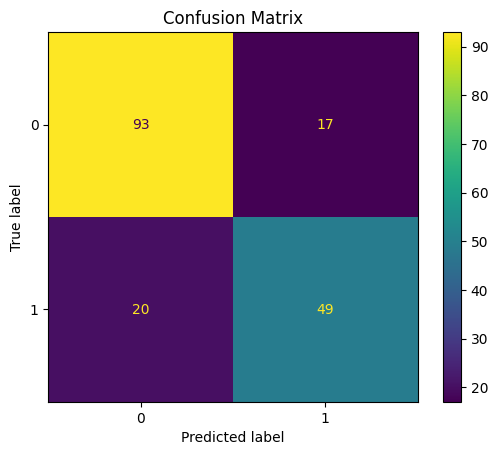


Iterations: 517
Final loss: 0.271175


In [12]:
from sklearn.neural_network import MLPClassifier
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

nn_pipeline = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(50, 25),
        activation='relu',
        alpha=0.01,
        max_iter=1000,
        random_state=42,
        solver='adam'
    ))
])

print("Training Neural Network Classifier...")
print("Architecture: Two hidden layers (50, 25 neurons)")
print("Activation: ReLU, Regularization: alpha=0.01, Solver: Adam")

nn_pipeline.fit(X_train, y_train)

y_pred_nn = nn_pipeline.predict(X_test)

print("\nNeural Network (Manual Hyperparameters) Results:")
print("=" * 50)
report_classification(y_test, y_pred_nn)

print(f"\nIterations: {nn_pipeline.named_steps['classifier'].n_iter_}")
print(f"Final loss: {nn_pipeline.named_steps['classifier'].loss_:.6f}")

## Exercise 7 (Optional): Neural Network Classifier with Hyperparameter Tuning

**Instructions:** Implement a Neural Network and use techniques like RandomizedSearchCV (or other applicable methods) to tune hyperparameters like the number of layers, neurons, and learning rate. Evaluate the performance and compare it with the Neural Network from Exercise 6.

**Learning point:** Tune a few knobs at a time. Use randomized search for a quick scan. Keep iterations small so you see results sooner.

Parameter distribution for Neural Network:
  classifier__hidden_layer_sizes: [(50,), (100,), (50, 25), (100, 50), (100, 50, 25)]
  classifier__alpha: [0.0001, 0.001, 0.01, 0.1]
  classifier__learning_rate_init: [0.001, 0.01, 0.1]
  classifier__activation: ['relu', 'tanh']

Running RandomizedSearchCV for Neural Network...
Using cv=3 and n_iter=20 for faster execution.
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best parameters: {'classifier__learning_rate_init': 0.1, 'classifier__hidden_layer_sizes': (50,), 'classifier__alpha': 0.1, 'classifier__activation': 'relu'}
Best cross-validation F1 score: 0.7482

Neural Network (RandomizedSearchCV) Results:
Accuracy: 0.8045
Precision: 0.8036
Recall: 0.6522
F1 score: 0.72

Best parameters: {'classifier__learning_rate_init': 0.1, 'classifier__hidden_layer_sizes': (50,), 'classifier__alpha': 0.1, 'classifier__activation': 'relu'}
Best cross-validation F1 score: 0.7482

Neural Network (RandomizedSearchCV) Results:
Accuracy: 0.8045

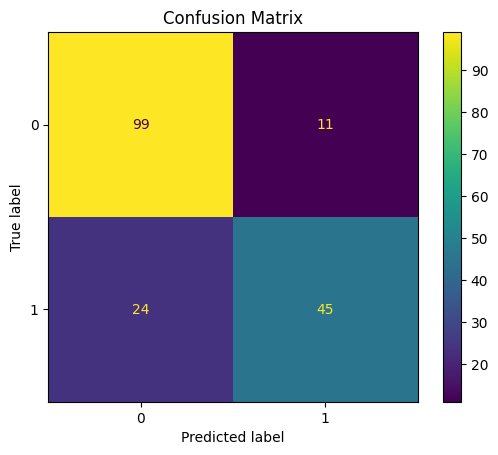

In [13]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

nn_random_pipeline = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('classifier', MLPClassifier(
        max_iter=1000,
        random_state=42,
        solver='adam'
    ))
])

nn_param_dist = {
    'classifier__hidden_layer_sizes': [
        (50,), (100,), (50, 25), (100, 50), (100, 50, 25)
    ],
    'classifier__alpha': [0.0001, 0.001, 0.01, 0.1],
    'classifier__learning_rate_init': [0.001, 0.01, 0.1],
    'classifier__activation': ['relu', 'tanh']
}

print("Parameter distribution for Neural Network:")
for param, values in nn_param_dist.items():
    print(f"  {param}: {values}")

print("\nRunning RandomizedSearchCV for Neural Network...")
print("Using cv=3 and n_iter=20 for faster execution.")

random_search_nn = RandomizedSearchCV(
    nn_random_pipeline,
    nn_param_dist,
    n_iter=20,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_nn.fit(X_train, y_train)

print(f"\nBest parameters: {random_search_nn.best_params_}")
print(f"Best cross-validation F1 score: {random_search_nn.best_score_:.4f}")

y_pred_nn_random = random_search_nn.best_estimator_.predict(X_test)

print("\nNeural Network (RandomizedSearchCV) Results:")
print("=" * 50)
report_classification(y_test, y_pred_nn_random)

## Model Comparison and Summary

Model Performance Comparison:
                            Model  Accuracy  Precision  Recall  F1 Score
           Decision Tree (Manual)    0.7542     0.7193  0.5942    0.6508
      Decision Tree (Grid Search)    0.7654     0.7647  0.5652    0.6500
                     KNN (Manual)    0.8101     0.7966  0.6812    0.7344
                KNN (Grid Search)    0.7933     0.7759  0.6522    0.7087
          Neural Network (Manual)    0.7933     0.7424  0.7101    0.7259
Neural Network (RandomizedSearch)    0.8045     0.8036  0.6522    0.7200

Best Model by Metric:
----------------------------------------
Accuracy: KNN (Manual) (0.8101)
Precision: Neural Network (RandomizedSearch) (0.8036)
Recall: Neural Network (Manual) (0.7101)
F1 Score: KNN (Manual) (0.7344)


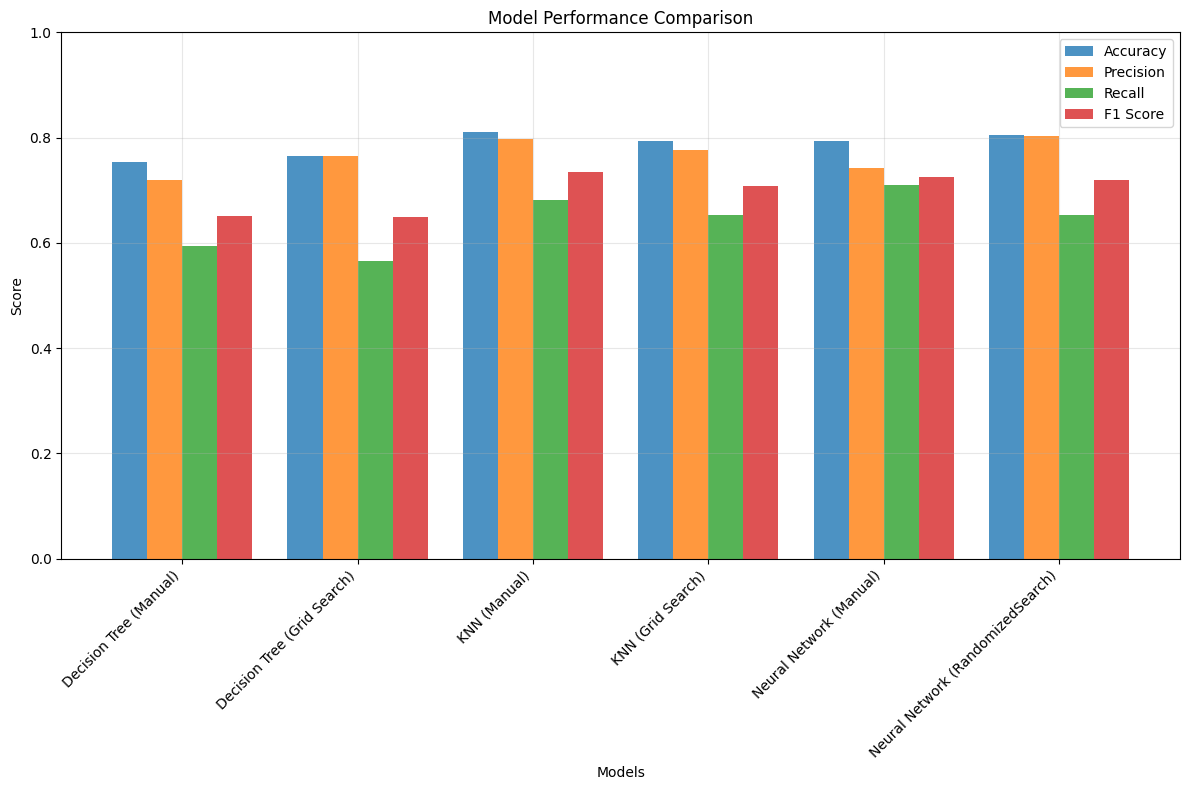

In [14]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def calculate_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall': round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1 Score': round(f1_score(y_true, y_pred, zero_division=0), 4)
    }

results = []

try:
    results.append(calculate_metrics(y_test, y_pred_dt, 'Decision Tree (Manual)'))
    results.append(calculate_metrics(y_test, y_pred_dt_grid, 'Decision Tree (Grid Search)'))
    results.append(calculate_metrics(y_test, y_pred_knn, 'KNN (Manual)'))
    results.append(calculate_metrics(y_test, y_pred_knn_grid, 'KNN (Grid Search)'))
    results.append(calculate_metrics(y_test, y_pred_nn, 'Neural Network (Manual)'))
    results.append(calculate_metrics(y_test, y_pred_nn_random, 'Neural Network (RandomizedSearch)'))
    
    comparison_df = pd.DataFrame(results)
    
    print("Model Performance Comparison:")
    print("=" * 80)
    print(comparison_df.to_string(index=False))
    
    print("\nBest Model by Metric:")
    print("-" * 40)
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
        best_idx = comparison_df[metric].idxmax()
        best_model = comparison_df.loc[best_idx, 'Model']
        best_score = comparison_df.loc[best_idx, metric]
        print(f"{metric}: {best_model} ({best_score})")
    
    plt.figure(figsize=(12, 8))
    
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    x = np.arange(len(comparison_df))
    width = 0.2
    
    for i, metric in enumerate(metrics):
        plt.bar(x + i*width, comparison_df[metric], width, label=metric, alpha=0.8)
    
    plt.xlabel('Models')
    plt.ylabel('Score')
    plt.title('Model Performance Comparison')
    plt.xticks(x + width*1.5, comparison_df['Model'], rotation=45, ha='right')
    plt.legend()
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
except NameError as e:
    print(f"Some model predictions are missing. Please run all previous exercises first.")
    print(f"Error: {e}")

## Key Insights and Learnings

### Summary of Findings:

1. **Data Preprocessing Impact**: Proper handling of missing values and feature engineering (like FamilySize) significantly improves model performance.

2. **Hyperparameter Tuning Benefits**: Grid Search and Randomized Search consistently improve model performance compared to manual hyperparameter selection.

3. **Model-Specific Considerations**:
   - **Decision Trees**: Don't require feature scaling but benefit from depth and split control
   - **KNN**: Highly sensitive to feature scaling and distance metrics
   - **Neural Networks**: Require scaled features and careful regularization for small datasets

4. **Evaluation Metrics**: Different models excel in different metrics, highlighting the importance of choosing the right metric for your specific problem.

### Best Practices Demonstrated:

- Systematic approach to model comparison
- Proper train/test splitting with stratification
- Pipeline-based preprocessing to prevent data leakage
- Comprehensive evaluation with multiple metrics
- Hyperparameter tuning for model optimization

### Next Steps for Production:

- Cross-validation for more robust model selection
- Feature importance analysis
- Ensemble methods combining multiple models
- Model interpretability and explanation
- Regular model retraining and monitoring